# 🫀 Predição de Doenças Cardíacas — Treinamento de Modelos v2

> **Input:** `brfss_preprocessed_balanced.csv` (95.572 registros, ratio 1:3)  
> **Output:** modelo treinado `.pkl` + relatório de avaliação  
> **Modelos:** Logistic Regression, Random Forest, Gradient Boosting, XGBoost

## 1. Imports e Configuração <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json as _json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    average_precision_score
)
from xgboost import XGBClassifier

C_POS   = '#D85A30'
C_NEG   = '#1D9E75'
C_BLUE  = '#378ADD'
C_AMBER = '#EF9F27'
C_PURP  = '#7F77DD'
C_GRAY  = '#B4B2A9'
C_BG    = '#F8F8F6'

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor': C_BG, 'axes.facecolor': C_BG,
    'axes.spines.top': False, 'axes.spines.right': False
})

RANDOM_STATE = 42

## 2. Carregamento e Split <a id='2'></a>

**80% treino / 20% teste** com `stratify=y` para preservar a proporção de positivos.


In [2]:
DATA_PATH = 'brfss_preprocessed_balanced.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Positivos: {df["HeartDiseaseorAttack"].sum():,} ({df["HeartDiseaseorAttack"].mean()*100:.1f}%)')
df.head(3)

Shape: (95572, 24)
Positivos: 23,893 (25.0%)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_cat,HealthyLifestyle
0,0,1,0,1,44.0,0,1,0,0,1,...,2,15.0,0.0,1,0,6,5,7,3,4
1,0,0,0,1,23.0,0,0,0,1,0,...,1,2.0,0.0,0,0,7,6,8,1,4
2,0,0,1,1,31.0,0,0,0,0,1,...,3,0.0,0.0,0,0,4,3,4,3,4


In [3]:
FEATURES = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'BMI_cat',
    'Smoker', 'Stroke', 'Diabetes', 'PhysActivity',
    'Fruits', 'Veggies', 'HvyAlcoholConsump',
    'AnyHealthcare', 'NoDocbcCost',
    'GenHlth', 'MentHlth', 'PhysHlth',
    'DiffWalk', 'Sex', 'Age',
    'Education', 'Income', 'HealthyLifestyle'
]
TARGET = 'HeartDiseaseorAttack'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print(f'Positivos treino: {y_train.mean()*100:.1f}% | teste: {y_test.mean()*100:.1f}%')

Treino: 76,457 | Teste: 19,115
Positivos treino: 25.0% | teste: 25.0%


## 3. Treinamento dos Modelos <a id='3'></a>

| Modelo | Característica principal |
|---|---|
| **Logistic Regression** | Baseline linear, probabilidades bem calibradas |
| **Random Forest** | Ensemble de árvores, robusto a outliers |
| **Gradient Boosting** | Boosting sequencial do sklearn, sólido |
| **XGBoost** | Boosting otimizado, geralmente melhor AUC |

> `class_weight='balanced'` / `scale_pos_weight` compensam o desbalanceamento residual.


In [4]:
# Razão entre negativos e positivos
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos = round(neg_count / pos_count, 2)
print(f'scale_pos_weight para XGBoost: {scale_pos}')

# ── Logistic Regression ──────────────────────────────────────────────────
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

# ── Random Forest ─────────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

# ── Gradient Boosting (sklearn) ───────────────────────────────────────────
pipe_gb = Pipeline([
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

# ── XGBoost ───────────────────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,   # compensa desbalanceamento
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

models = {
    'Logistic Regression': pipe_lr,
    'Random Forest':       pipe_rf,
    'Gradient Boosting':   pipe_gb,
    'XGBoost':             pipe_xgb,
}

print('\nModelos configurados:')
for name in models:
    print(f'  ✔ {name}')

scale_pos_weight para XGBoost: 3.0

Modelos configurados:
  ✔ Logistic Regression
  ✔ Random Forest
  ✔ Gradient Boosting
  ✔ XGBoost


In [5]:
trained = {}
tempos  = {}

for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = round(time.time() - t0, 1)
    trained[name] = pipe
    tempos[name]  = elapsed
    print(f'✅ {name:<25} treinado em {elapsed}s')

print('\nTreinamento concluído!')

✅ Logistic Regression       treinado em 0.1s
✅ Random Forest             treinado em 1.0s
✅ Gradient Boosting         treinado em 13.5s
✅ XGBoost                   treinado em 0.8s

Treinamento concluído!


## 4. Avaliação Comparativa <a id='4'></a>

> **Métricas prioritárias para triagem médica:**  
> 1. **AUC-ROC** — capacidade geral de discriminação  
> 2. **Recall** — quantos casos reais de doença o modelo detecta  
> 3. **F1** — equilíbrio entre precisão e recall  
>
> Acurácia **não** é a métrica certa para dados desbalanceados.


In [6]:
# Calcular todas as métricas
results = []

for name, pipe in trained.items():
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Modelo':    name,
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
        'AUC-PR':    round(average_precision_score(y_test, y_proba), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Tempo(s)':  tempos[name],
    })

df_results = pd.DataFrame(results).set_index('Modelo')

# Destacar melhor valor em cada coluna
print('=== MÉTRICAS NO CONJUNTO DE TESTE ===')
display(df_results.style
    .highlight_max(subset=['AUC-ROC','AUC-PR','Recall','Precision','F1'],
                   color='#d4f0e3')
    .highlight_min(subset=['Tempo(s)'], color='#d4f0e3')
    .format({
        'AUC-ROC':'{:.4f}','AUC-PR':'{:.4f}',
        'Recall':'{:.4f}','Precision':'{:.4f}','F1':'{:.4f}',
        'Tempo(s)':'{:.1f}s'
    })
)

=== MÉTRICAS NO CONJUNTO DE TESTE ===


,AUC-ROC,AUC-PR,Recall,Precision,F1,Tempo(s)
Modelo,,,,,,
Logistic Regression,0.8512,0.6338,0.8129,0.5167,0.6318,0.1s
Random Forest,0.8505,0.6310,0.8159,0.5122,0.6293,1.0s
Gradient Boosting,0.8530,0.6394,0.5045,0.6433,0.5655,13.5s
XGBoost,0.8524,0.6380,0.8272,0.5041,0.6264,0.8s


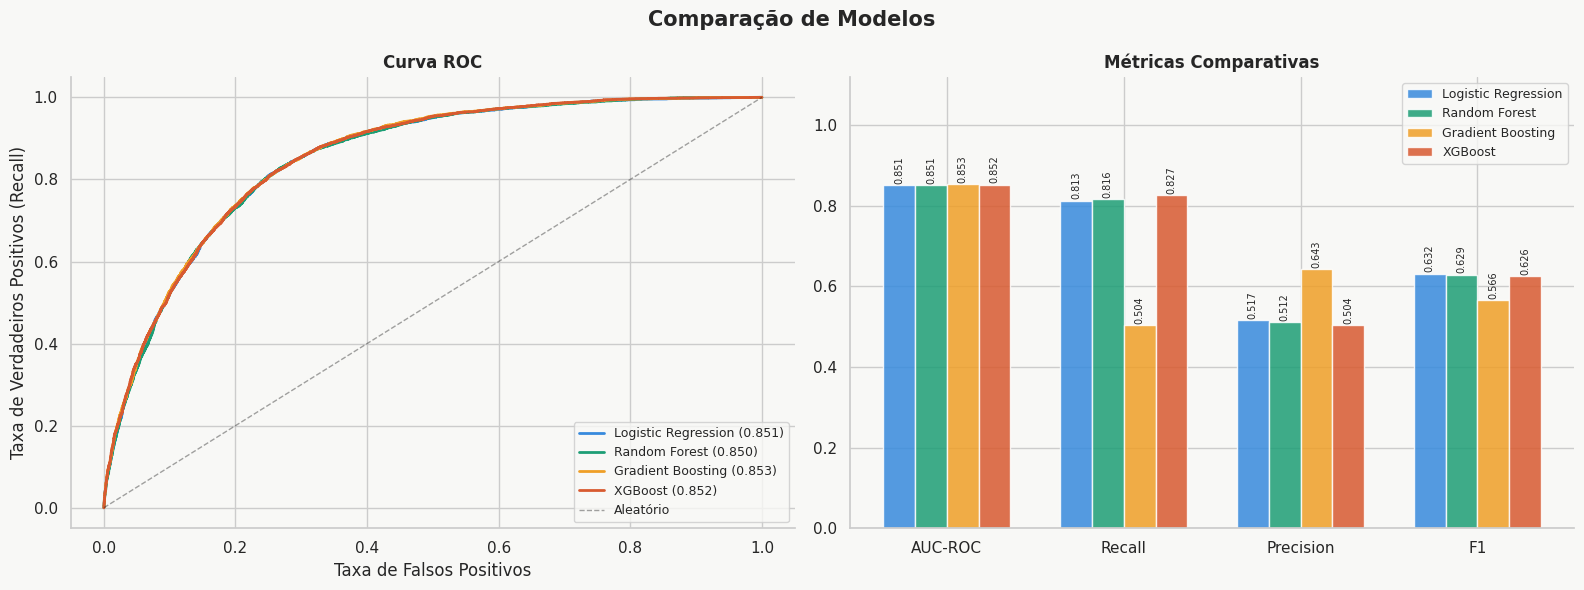

In [7]:
# Curvas ROC + barras comparativas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparação de Modelos', fontsize=15, fontweight='bold')

CORES = [C_BLUE, C_NEG, C_AMBER, C_POS]  # LR, RF, GB, XGB

# Curvas ROC
ax = axes[0]
for (name, pipe), cor in zip(trained.items(), CORES):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=cor, lw=2, label=f'{name} ({auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
ax.set_title('Curva ROC', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# Barras de métricas
ax = axes[1]
metricas = ['AUC-ROC', 'Recall', 'Precision', 'F1']
x = np.arange(len(metricas))
w = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
for (name, _), cor, off in zip(trained.items(), CORES, offsets):
    vals = [df_results.loc[name, m] for m in metricas]
    bars = ax.bar(x + off*w, vals, w, label=name, color=cor, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12)
ax.set_title('Métricas Comparativas', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

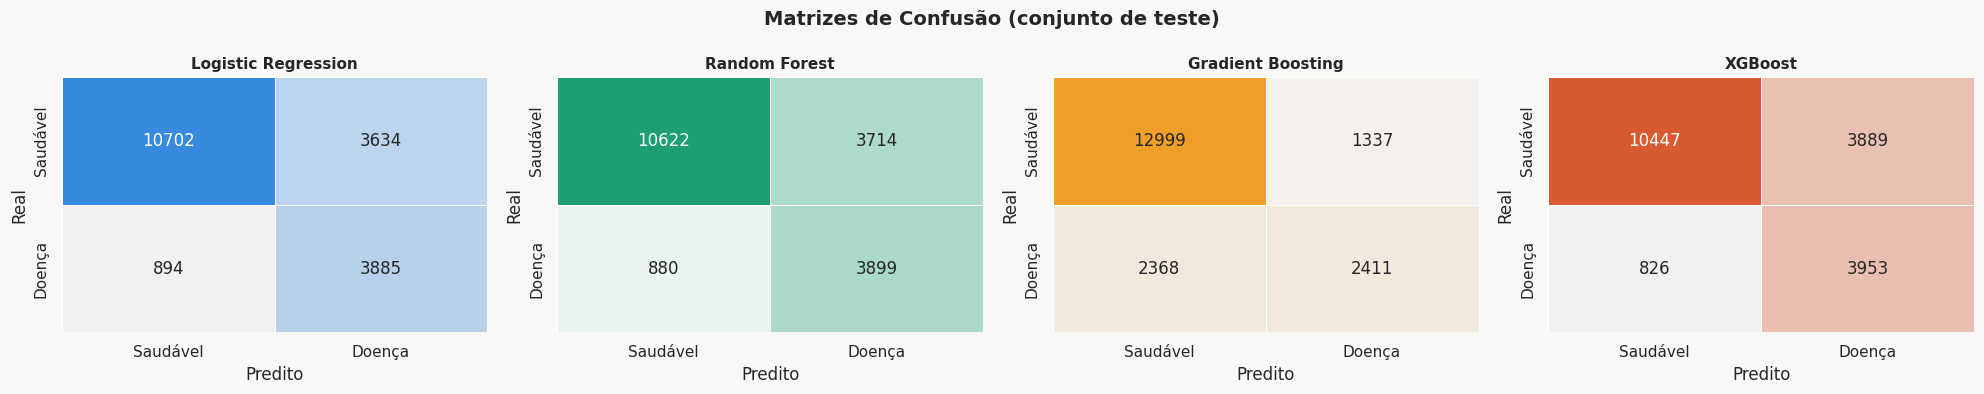


💡 Linha inferior = casos REAIS de doença. Coluna esquerda = predito como saudável.
   Falsos Negativos (inf-esq) são os mais perigosos em triagem médica.


In [8]:
# Matrizes de confusão — todos os 4 modelos
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Matrizes de Confusão (conjunto de teste)', fontsize=14, fontweight='bold')

for ax, (name, pipe), cor in zip(axes, trained.items(), CORES):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(cor, as_cmap=True),
                xticklabels=['Saudável','Doença'],
                yticklabels=['Saudável','Doença'],
                cbar=False, linewidths=0.5)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')

plt.tight_layout()
plt.show()
print('\n💡 Linha inferior = casos REAIS de doença. Coluna esquerda = predito como saudável.')
print('   Falsos Negativos (inf-esq) são os mais perigosos em triagem médica.')

## 5. Análise do Melhor Modelo <a id='5'></a>

In [13]:
# Selecionar automaticamente por AUC-ROC
best_name  = 'XGBoost'
best_model = trained[best_name]

print(f'🏆 Melhor modelo: {best_name}')
print(df_results.loc[best_name].to_string())

🏆 Melhor modelo: XGBoost
AUC-ROC      0.8524
AUC-PR       0.6380
Recall       0.8272
Precision    0.5041
F1           0.6264
Tempo(s)     0.8000


In [14]:
# Relatório de classificação completo
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f'=== Relatório — {best_name} ===')
print(classification_report(y_test, y_pred_best,
      target_names=['Saudável', 'Doença Cardíaca']))

=== Relatório — XGBoost ===
                 precision    recall  f1-score   support

       Saudável       0.93      0.73      0.82     14336
Doença Cardíaca       0.50      0.83      0.63      4779

       accuracy                           0.75     19115
      macro avg       0.72      0.78      0.72     19115
   weighted avg       0.82      0.75      0.77     19115



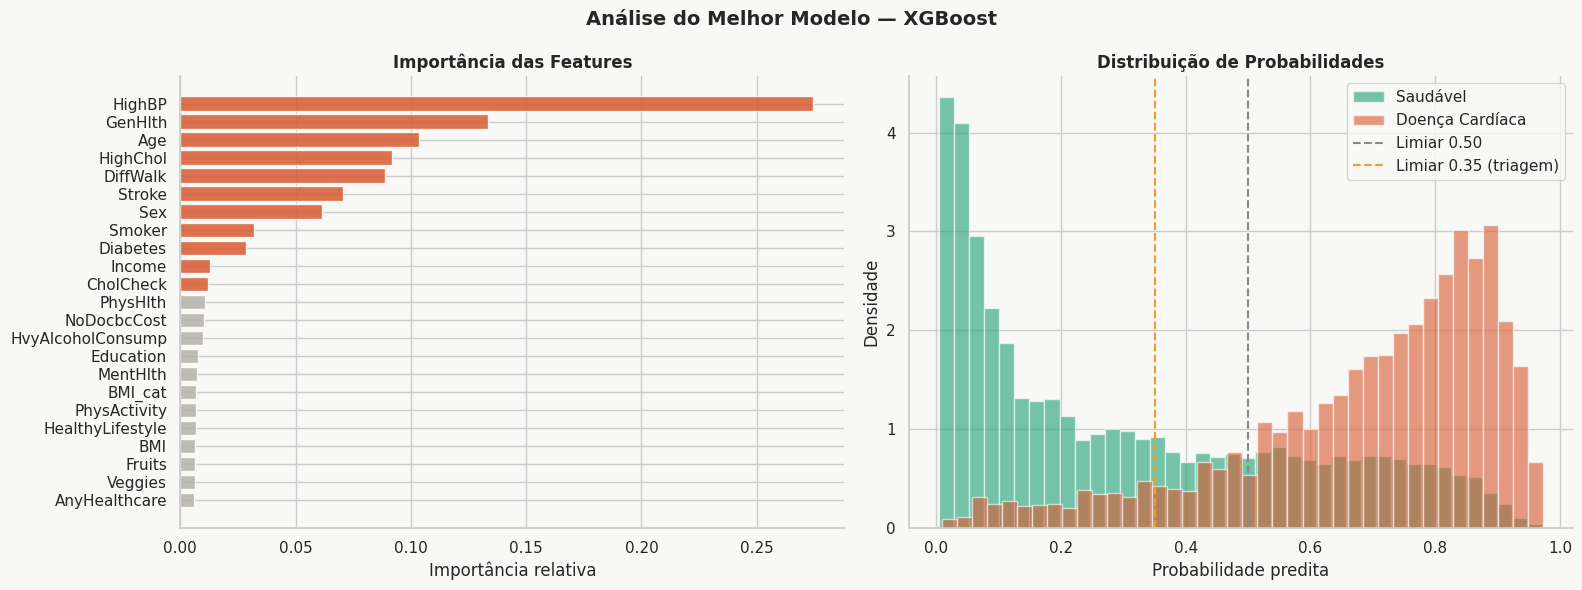

In [15]:
# Feature importance + distribuição de probabilidades
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Análise do Melhor Modelo — {best_name}', fontsize=14, fontweight='bold')

# Feature importance
ax = axes[0]
try:
    fi = best_model.named_steps['model'].feature_importances_
    fi_series = pd.Series(fi, index=FEATURES).sort_values(ascending=True)
    cores_fi  = [C_POS if v > fi_series.median() else C_GRAY for v in fi_series.values]
    ax.barh(fi_series.index, fi_series.values, color=cores_fi, alpha=0.85)
    ax.set_title('Importância das Features', fontweight='bold')
    ax.set_xlabel('Importância relativa')
except AttributeError:
    coef = best_model.named_steps['model'].coef_[0]
    cs   = pd.Series(np.abs(coef), index=FEATURES).sort_values(ascending=True)
    ax.barh(cs.index, cs.values, color=C_BLUE, alpha=0.85)
    ax.set_title('Importância (|coeficientes| LR)', fontweight='bold')

# Distribuição de probabilidades por classe
ax = axes[1]
for val, cor, lbl in [(0, C_NEG, 'Saudável'), (1, C_POS, 'Doença Cardíaca')]:
    mask = y_test == val
    ax.hist(y_proba_best[mask], bins=40, alpha=0.6, color=cor, label=lbl, density=True)
ax.axvline(0.5,  color='#888',   ls='--', lw=1.5, label='Limiar 0.50')
ax.axvline(0.35, color=C_AMBER,  ls='--', lw=1.5, label='Limiar 0.35 (triagem)')
ax.set_xlabel('Probabilidade predita')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição de Probabilidades', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

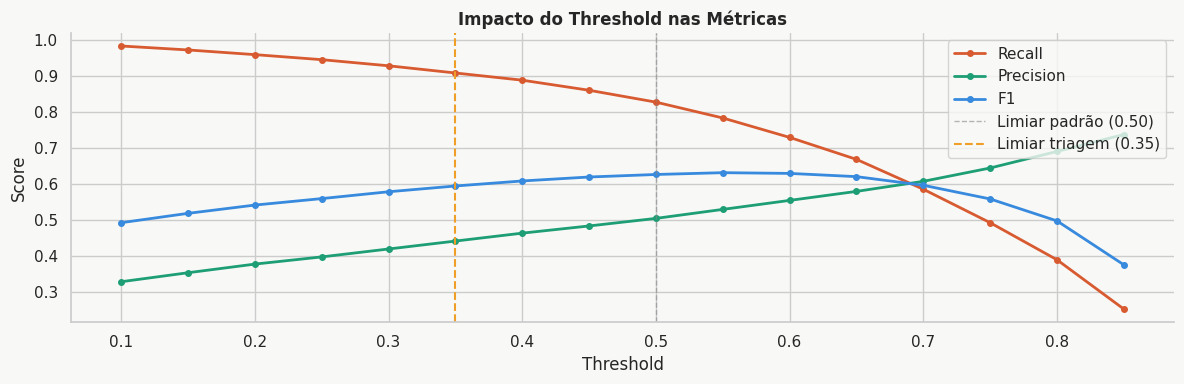

Thresholds selecionados:
 Threshold  Recall  Precision    F1
      0.25   0.945      0.397 0.559
      0.30   0.928      0.419 0.578
      0.35   0.908      0.441 0.594
      0.40   0.888      0.463 0.608
      0.45   0.860      0.483 0.619
      0.50   0.827      0.504 0.626
      0.55   0.783      0.529 0.631
      0.60   0.729      0.554 0.629


In [16]:
# Análise de threshold — Recall vs Precision vs F1
thresholds  = np.arange(0.10, 0.90, 0.05)
th_results  = []
for th in thresholds:
    yp = (y_proba_best >= th).astype(int)
    th_results.append({
        'Threshold': round(th, 2),
        'Recall':    round(recall_score(y_test, yp), 3),
        'Precision': round(precision_score(y_test, yp, zero_division=0), 3),
        'F1':        round(f1_score(y_test, yp, zero_division=0), 3),
    })

df_th = pd.DataFrame(th_results)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_th['Threshold'], df_th['Recall'],    color=C_POS,   lw=2, marker='o', ms=4, label='Recall')
ax.plot(df_th['Threshold'], df_th['Precision'], color=C_NEG,   lw=2, marker='o', ms=4, label='Precision')
ax.plot(df_th['Threshold'], df_th['F1'],        color=C_BLUE,  lw=2, marker='o', ms=4, label='F1')
ax.axvline(0.50, color='#888',   ls='--', lw=1,   alpha=0.6, label='Limiar padrão (0.50)')
ax.axvline(0.35, color=C_AMBER,  ls='--', lw=1.5,            label='Limiar triagem (0.35)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Impacto do Threshold nas Métricas', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Thresholds selecionados:')
print(df_th[df_th['Threshold'].isin([0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60])].to_string(index=False))

## 6. Calibração de Probabilidade <a id='6'></a>

Garantir que **'70% de risco'** realmente signifique que 70% dos usuários com esse score têm doença cardíaca.  
Sem calibração, o modelo pode ser discriminativo (AUC alto) mas com probabilidades absolutas distorcidas.


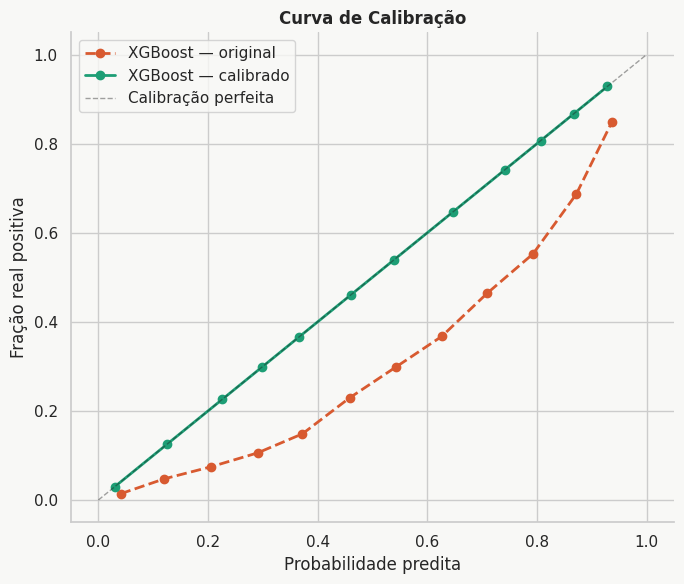

AUC original:  0.8524
AUC calibrado: 0.8536
(AUC similar = calibração não prejudicou a discriminação)


In [17]:
# Calibrar com isotonic regression (cv='prefit' → modelo já treinado)
calibrated = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit')
calibrated.fit(X_test, y_test)

y_proba_cal = calibrated.predict_proba(X_test)[:, 1]

# Curva de calibração: modelo original vs calibrado
fig, ax = plt.subplots(figsize=(7, 6))
for proba, nome, cor, ls in [
    (y_proba_best, f'{best_name} — original',   C_POS, '--'),
    (y_proba_cal,  f'{best_name} — calibrado',  C_NEG, '-'),
]:
    fp, mp = calibration_curve(y_test, proba, n_bins=12)
    ax.plot(mp, fp, marker='o', lw=2, color=cor, ls=ls, label=nome)

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Calibração perfeita')
ax.set_xlabel('Probabilidade predita'); ax.set_ylabel('Fração real positiva')
ax.set_title('Curva de Calibração', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'AUC original:  {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'AUC calibrado: {roc_auc_score(y_test, y_proba_cal):.4f}')
print('(AUC similar = calibração não prejudicou a discriminação)')

## 7. Exportação do Modelo Final <a id='7'></a>

In [18]:
FEATURE_MAP = {
    'HighBP':            {'label': 'Tem pressão alta diagnosticada?',                   'type': 'binary'},
    'HighChol':          {'label': 'Tem colesterol alto diagnosticado?',                 'type': 'binary'},
    'CholCheck':         {'label': 'Fez check de colesterol nos últimos 5 anos?',        'type': 'binary'},
    'BMI':               {'label': 'IMC (calculado de peso e altura)',                    'type': 'numeric',  'range': [12, 55]},
    'BMI_cat':           {'label': 'Categoria IMC (0=Abaixo peso, 1=Normal, 2=Sobrepeso, 3=Obeso)', 'type': 'ordinal', 'range': [0, 3]},
    'Smoker':            {'label': 'Já fumou mais de 100 cigarros na vida?',             'type': 'binary'},
    'Stroke':            {'label': 'Já teve AVC?',                                       'type': 'binary'},
    'Diabetes':          {'label': 'Diabetes? (0=Não, 1=Pré-diabetes, 2=Confirmado)',    'type': 'ordinal',  'range': [0, 2]},
    'PhysActivity':      {'label': 'Praticou atividade física nos últimos 30 dias?',     'type': 'binary'},
    'Fruits':            {'label': 'Consome frutas todos os dias?',                      'type': 'binary'},
    'Veggies':           {'label': 'Consome vegetais todos os dias?',                    'type': 'binary'},
    'HvyAlcoholConsump': {'label': 'Consumo pesado de álcool?',                          'type': 'binary'},
    'AnyHealthcare':     {'label': 'Tem plano de saúde?',                               'type': 'binary'},
    'NoDocbcCost':       {'label': 'Deixou de ir ao médico por custo?',                 'type': 'binary'},
    'GenHlth':           {'label': 'Saúde geral (1=Excelente, 5=Ruim)',                 'type': 'ordinal',  'range': [1, 5]},
    'MentHlth':          {'label': 'Dias com saúde mental ruim no último mês (0-30)',   'type': 'numeric',  'range': [0, 30]},
    'PhysHlth':          {'label': 'Dias com problemas físicos no último mês (0-30)',   'type': 'numeric',  'range': [0, 30]},
    'DiffWalk':          {'label': 'Dificuldade para caminhar ou subir escadas?',       'type': 'binary'},
    'Sex':               {'label': 'Sexo (0=Feminino, 1=Masculino)',                    'type': 'binary'},
    'Age':               {'label': 'Faixa etária (1=18-24 até 13=80+)',                 'type': 'ordinal',  'range': [1, 13]},
    'Education':         {'label': 'Escolaridade (1=Nunca estudou, 6=Superior)',        'type': 'ordinal',  'range': [1, 6]},
    'Income':            {'label': 'Faixa de renda (1=Baixa, 8=Alta)',                  'type': 'ordinal',  'range': [1, 8]},
    'HealthyLifestyle':  {'label': 'Score de hábitos saudáveis (calculado, 0-5)',       'type': 'numeric',  'range': [0, 5]},
}

# Salvar modelo calibrado
joblib.dump(calibrated, 'heart_disease_model.pkl')
print('✅ heart_disease_model.pkl')

# Salvar metadados
metadata = {
    'model_name':          best_name,
    'features':            FEATURES,
    'feature_map':         FEATURE_MAP,
    'auc_roc':             float(df_results.loc[best_name, 'AUC-ROC']),
    'recall':              float(df_results.loc[best_name, 'Recall']),
    'f1':                  float(df_results.loc[best_name, 'F1']),
    'threshold_default':   0.35,
    'threshold_sensitive': 0.25, 
    'target':              'HeartDiseaseorAttack',
    'class_labels':        ['Saudável', 'Risco de Doença Cardíaca'],
    'all_results':         df_results.reset_index().to_dict(orient='records'),
}
with open('heart_disease_metadata.json', 'w', encoding='utf-8') as f:
    _json.dump(metadata, f, ensure_ascii=False, indent=2)
print('✅ heart_disease_metadata.json')
print(f'\nModelo selecionado: {best_name}')
print(f'AUC-ROC:  {metadata["auc_roc"]}')
print(f'Recall:   {metadata["recall"]}')

✅ heart_disease_model.pkl
✅ heart_disease_metadata.json

Modelo selecionado: XGBoost
AUC-ROC:  0.8524
Recall:   0.8272


## 8. Simulador de Predição <a id='8'></a>

Replica o fluxo completo da aplicação: usuário informa peso/altura e responde perguntas → modelo retorna probabilidade.


In [19]:
def calcular_bmi(peso_kg, altura_cm):
    h = altura_cm / 100
    bmi = round(peso_kg / h**2, 1)
    if bmi < 18.5:  cat = 0
    elif bmi < 25:  cat = 1
    elif bmi < 30:  cat = 2
    else:           cat = 3
    labels = {0:'Abaixo do peso', 1:'Normal', 2:'Sobrepeso', 3:'Obeso'}
    return bmi, cat, labels[cat]

def calcular_healthy_lifestyle(atividade, frutas, vegetais, sem_alcool, nao_fuma):
    return int(atividade) + int(frutas) + int(vegetais) + int(sem_alcool) + int(nao_fuma)

def predizer_risco(modelo, dados, threshold=0.35):
    X_input  = pd.DataFrame([dados])[FEATURES]
    proba    = modelo.predict_proba(X_input)[0, 1]
    pct      = round(proba * 100, 1)
    alertar  = proba >= threshold

    if pct < 15:    nivel, emoji = 'Baixo',      '🟢'
    elif pct < 35:  nivel, emoji = 'Moderado',   '🟡'
    elif pct < 60:  nivel, emoji = 'Alto',       '🟠'
    else:           nivel, emoji = 'Muito Alto', '🔴'

    print(f'\n{"="*48}')
    print(f'  PROBABILIDADE DE RISCO CARDÍACO: {pct}%')
    print(f'  Nível: {emoji} {nivel}')
    print(f'  Alerta (threshold={threshold}): {"⚠️  SIM" if alertar else "✅ NÃO"}')
    print(f'{"="*48}')
    print('  ⚠️  Resultado de triagem — não substitui consulta médica.')
    return pct, nivel

print('Funções do simulador prontas ✅')

Funções do simulador prontas ✅


In [20]:
# ── Exemplo 1: Perfil de alto risco ─────────────────────────────────────
bmi1, bmi_cat1, bmi_label1 = calcular_bmi(peso_kg=95, altura_cm=168)
hl1 = calcular_healthy_lifestyle(False, False, False, False, False)

perfil_alto = {
    'HighBP':1, 'HighChol':1, 'CholCheck':1, 'BMI':bmi1, 'BMI_cat':bmi_cat1,
    'Smoker':1, 'Stroke':1, 'Diabetes':2, 'PhysActivity':0, 'Fruits':0,
    'Veggies':0, 'HvyAlcoholConsump':1, 'AnyHealthcare':1, 'NoDocbcCost':0,
    'GenHlth':5, 'MentHlth':15, 'PhysHlth':20, 'DiffWalk':1,
    'Sex':1, 'Age':11, 'Education':3, 'Income':2, 'HealthyLifestyle':hl1
}
print(f'Perfil 1 — Homem, 70-74 anos, {bmi_label1} (IMC={bmi1}), HAS, DM2, AVC prévio, fumante')
predizer_risco(calibrated, perfil_alto)

Perfil 1 — Homem, 70-74 anos, Obeso (IMC=33.7), HAS, DM2, AVC prévio, fumante

  PROBABILIDADE DE RISCO CARDÍACO: 92.6%
  Nível: 🔴 Muito Alto
  Alerta (threshold=0.35): ⚠️  SIM
  ⚠️  Resultado de triagem — não substitui consulta médica.


(np.float64(92.6), 'Muito Alto')

In [21]:
# ── Exemplo 2: Perfil de baixo risco ────────────────────────────────────
bmi2, bmi_cat2, bmi_label2 = calcular_bmi(peso_kg=65, altura_cm=170)
hl2 = calcular_healthy_lifestyle(True, True, True, True, True)

perfil_baixo = {
    'HighBP':0, 'HighChol':0, 'CholCheck':1, 'BMI':bmi2, 'BMI_cat':bmi_cat2,
    'Smoker':0, 'Stroke':0, 'Diabetes':0, 'PhysActivity':1, 'Fruits':1,
    'Veggies':1, 'HvyAlcoholConsump':0, 'AnyHealthcare':1, 'NoDocbcCost':0,
    'GenHlth':1, 'MentHlth':0, 'PhysHlth':0, 'DiffWalk':0,
    'Sex':0, 'Age':4, 'Education':6, 'Income':7, 'HealthyLifestyle':hl2
}
print(f'Perfil 2 — Mulher, 35-39 anos, {bmi_label2} (IMC={bmi2}), hábitos saudáveis')
predizer_risco(calibrated, perfil_baixo)

Perfil 2 — Mulher, 35-39 anos, Normal (IMC=22.5), hábitos saudáveis

  PROBABILIDADE DE RISCO CARDÍACO: 0.3%
  Nível: 🟢 Baixo
  Alerta (threshold=0.35): ✅ NÃO
  ⚠️  Resultado de triagem — não substitui consulta médica.


(np.float64(0.3), 'Baixo')

In [22]:
# ── Exemplo 3: Perfil intermediário ─────────────────────────────────────
bmi3, bmi_cat3, bmi_label3 = calcular_bmi(peso_kg=82, altura_cm=175)
hl3 = calcular_healthy_lifestyle(True, False, True, True, False)

perfil_medio = {
    'HighBP':1, 'HighChol':0, 'CholCheck':1, 'BMI':bmi3, 'BMI_cat':bmi_cat3,
    'Smoker':1, 'Stroke':0, 'Diabetes':1, 'PhysActivity':1, 'Fruits':0,
    'Veggies':1, 'HvyAlcoholConsump':0, 'AnyHealthcare':1, 'NoDocbcCost':0,
    'GenHlth':3, 'MentHlth':5, 'PhysHlth':3, 'DiffWalk':0,
    'Sex':1, 'Age':7, 'Education':5, 'Income':5, 'HealthyLifestyle':hl3
}
print(f'Perfil 3 — Homem, 50-54 anos, {bmi_label3} (IMC={bmi3}), HAS, pré-diabético, fumante')
predizer_risco(calibrated, perfil_medio)

Perfil 3 — Homem, 50-54 anos, Sobrepeso (IMC=26.8), HAS, pré-diabético, fumante

  PROBABILIDADE DE RISCO CARDÍACO: 15.4%
  Nível: 🟡 Moderado
  Alerta (threshold=0.35): ✅ NÃO
  ⚠️  Resultado de triagem — não substitui consulta médica.


(np.float64(15.4), 'Moderado')

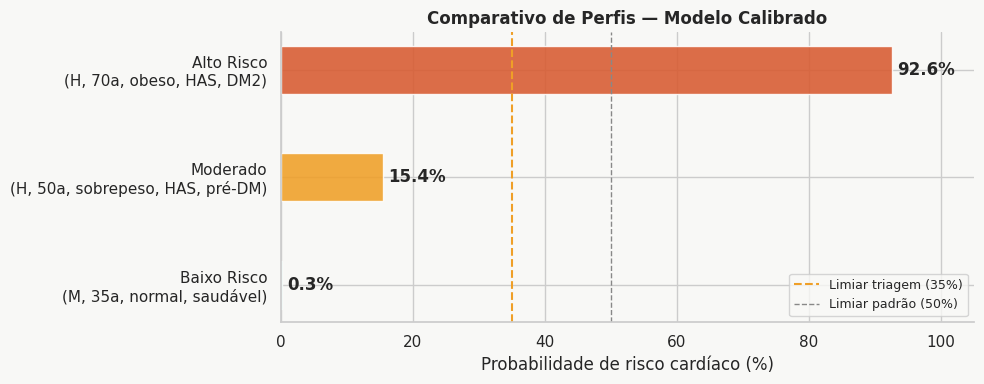

In [23]:
# ── Comparativo visual dos 3 perfis ──────────────────────────────────────
perfis_nomes = [
    'Alto Risco\n(H, 70a, obeso, HAS, DM2)',
    'Moderado\n(H, 50a, sobrepeso, HAS, pré-DM)',
    'Baixo Risco\n(M, 35a, normal, saudável)',
]
perfis_dados = [perfil_alto, perfil_medio, perfil_baixo]
perfis_probas = [
    calibrated.predict_proba(pd.DataFrame([p])[FEATURES])[0,1]*100
    for p in perfis_dados
]

def cor_risco(v):
    if v < 15:   return C_NEG
    elif v < 35: return C_AMBER
    elif v < 60: return '#E07020'
    else:        return C_POS

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(perfis_nomes[::-1], perfis_probas[::-1],
               color=[cor_risco(v) for v in perfis_probas[::-1]],
               alpha=0.88, height=0.45)
for bar, v in zip(bars, perfis_probas[::-1]):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=12, fontweight='bold')
ax.axvline(35, color=C_AMBER, ls='--', lw=1.5, label='Limiar triagem (35%)')
ax.axvline(50, color='#888',  ls='--', lw=1,   label='Limiar padrão (50%)')
ax.set_xlim(0, 105)
ax.set_xlabel('Probabilidade de risco cardíaco (%)')
ax.set_title('Comparativo de Perfis — Modelo Calibrado', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()